In [ ]:
import torch
print(torch.cuda.is_available())  # Deve retornar True se a GPU estiver sendo usada
print(torch.cuda.get_device_name(0))  # Deve exibir sua RTX 3050

Usando o dispositivo: cuda


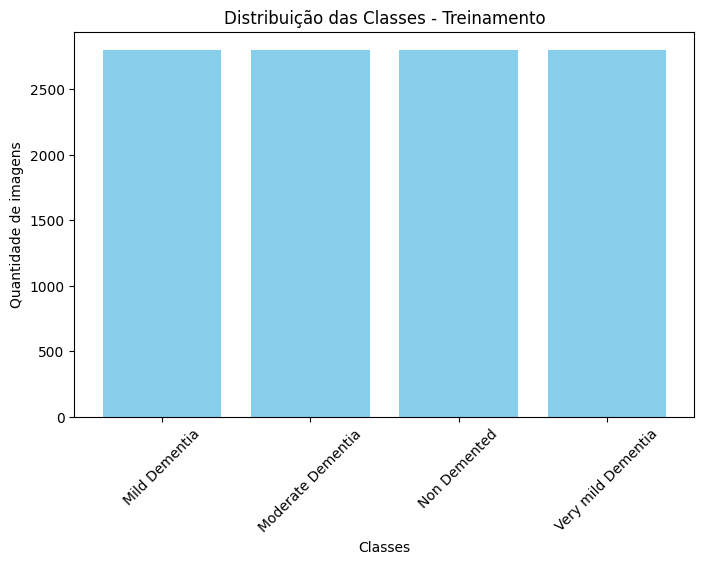

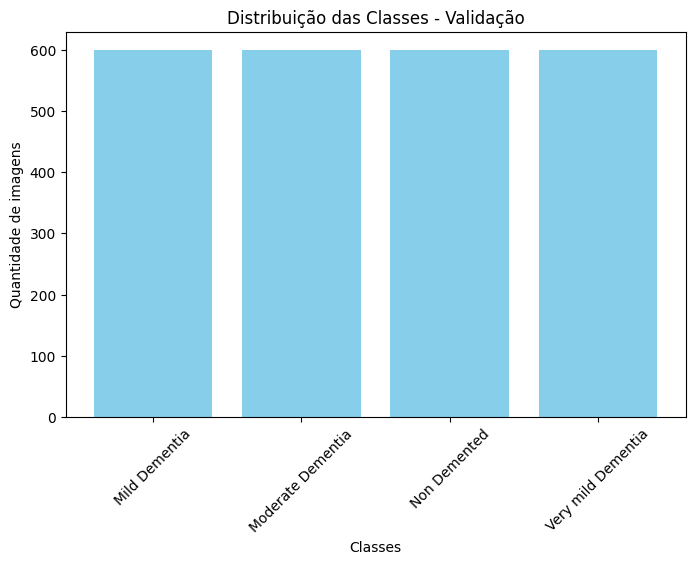

c:\Users\Lucas\Desktop\Lucas\DataScience\Projeto Integrador I\AlzheimerEarlyDetection\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lucas\Desktop\Lucas\DataScience\Projeto Integrador I\AlzheimerEarlyDetection\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.30292372410850865
Epoch 2, Loss: 0.09426507411857268
Epoch 3, Loss: 0.055650851718715526
Epoch 4, Loss: 0.05034549952334991
Epoch 5, Loss: 0.03865734216091888
Epoch 6, Loss: 0.03673148501789131
Epoch 7, Loss: 0.03593171229095398
Epoch 8, Loss: 0.013177571262775538
Epoch 9, Loss: 0.03372955856384319
Epoch 10, Loss: 0.03181505277031517


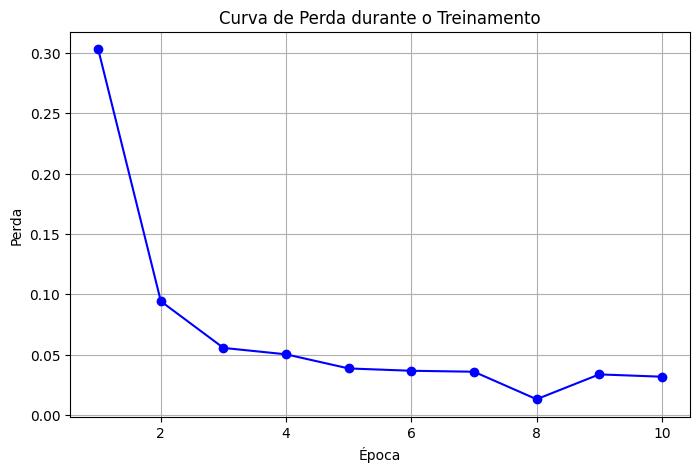

Relatório de Classificação:
                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00       600
 Moderate Dementia       1.00      1.00      1.00       600
      Non Demented       1.00      0.96      0.98       600
Very mild Dementia       0.96      1.00      0.98       600

          accuracy                           0.99      2400
         macro avg       0.99      0.99      0.99      2400
      weighted avg       0.99      0.99      0.99      2400



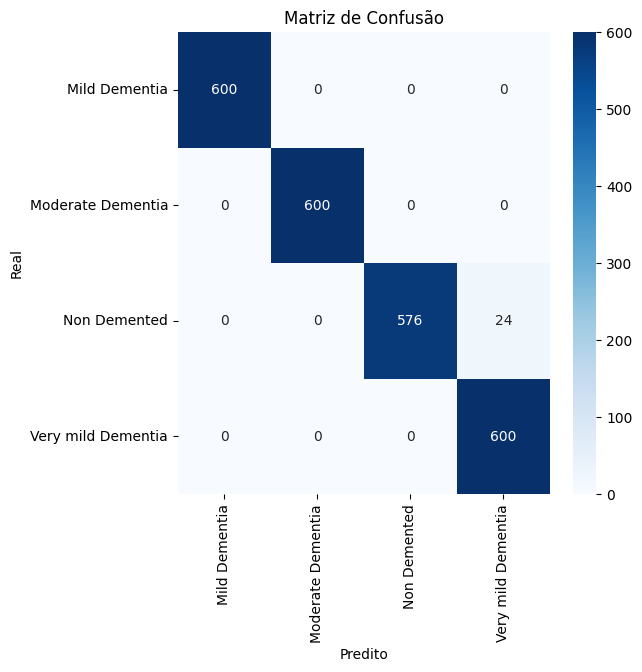

Treinamento e validação concluídos!


In [3]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import itertools

# Verifica se a GPU está disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando o dispositivo: {device}")

# Diretórios do dataset
data_dir = "datasets"
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"

# Transformações nas imagens
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ajuste para entrada do modelo
    transforms.RandomHorizontalFlip(),  # Data Augmentation
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalização
])

# Carregar os datasets
train_data = datasets.ImageFolder(root=train_dir, transform=transform)
val_data = datasets.ImageFolder(root=val_dir, transform=transform)
test_data = datasets.ImageFolder(root=test_dir, transform=transform)

# Criar DataLoaders para treino e validação
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4)

def plot_class_distribution(dataset, title):
    class_counts = [len([img for img, label in dataset.samples if label == i]) for i in range(len(dataset.classes))]
    plt.figure(figsize=(8, 5))
    plt.bar(dataset.classes, class_counts, color='skyblue')
    plt.xlabel("Classes")
    plt.ylabel("Quantidade de imagens")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_class_distribution(train_data, "Distribuição das Classes - Treinamento")
plot_class_distribution(val_data, "Distribuição das Classes - Validação")

# Carregar modelo pré-treinado
model = models.efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(train_data.classes))  # Ajusta para o número de classes
model = model.to(device)

# Configuração do otimizador e função de perda
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    model.train()
    train_losses = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    return model, train_losses

model, train_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)
torch.save(model.state_dict(), "alzheimer_model.pth")

def plot_loss_curve(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, marker='o', linestyle='-', color='blue')
    plt.xlabel("Época")
    plt.ylabel("Perda")
    plt.title("Curva de Perda durante o Treinamento")
    plt.grid()
    plt.show()

plot_loss_curve(train_losses)

# Validação do Modelo
def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

preds, labels = evaluate_model(model, val_loader)
print("Relatório de Classificação:")
print(classification_report(labels, preds, target_names=train_data.classes))

# Matriz de Confusão
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.show()

plot_confusion_matrix(labels, preds, train_data.classes)

print("Treinamento e validação concluídos!")
